# Real brain of CNN



We already know:

* CNN looks at small parts of image
* it uses **filters**
* output becomes **feature maps**

But now the next doubt comes naturally:

> **What exactly is a filter?**
> **Who makes it?**
> **Does the programmer write it?**
> **Or does CNN learn it by itself?**

That is exactly what we will do now.



---

# 🎬 Chapter 3 — Filters and Kernels in CNN

## 🎭 Characters

👩 **Riya**
👨‍🏫 **Professor Arjun**
🤖 **Milo**

---

# 🌅 Scene: The Tiny Detective Glass

Professor Arjun draws a tiny square on the board.

Riya asks:

> **Sir, this small square that moves on the image… what exactly is it?**

Professor Arjun smiles.

> **That tiny square is called a filter or kernel. It is like a small detective glass.**

Milo writes on the board:

```text
Filter / Kernel = A small matrix that scans the image to detect a pattern
```

---

# 🧠 Step 1 — Filter and Kernel: Are they same?

For beginner learning, yes.

You will hear both words:

```text
Filter
Kernel
```

In most classroom explanations, both are used almost like the same thing.

So for now students can remember:

```text
Filter = Kernel
```

That keeps things simple.

---

# 🧠 Step 2 — What does a filter look like?

A filter is just a **small box of numbers**.

Example:

```text
[ 1  0 -1 ]
[ 1  0 -1 ]
[ 1  0 -1 ]
```

This is a **3 × 3** filter.

That means:

* 3 rows
* 3 columns
* total 9 values

Another example:

```text
[ 1  1  1 ]
[ 0  0  0 ]
[-1 -1 -1 ]
```

Another one:

```text
[ 0  1  0 ]
[ 1 -4  1 ]
[ 0  1  0 ]
```

Each filter tries to respond strongly to some pattern.

---

# 😄 Funny intuition

Professor Arjun says:

> **Think of filters like different teachers checking answer sheets.**
>
> One teacher is very good at finding spelling mistakes.
> Another catches missing steps.
> Another checks handwriting style.

Same way:

* one filter may notice vertical edges
* one filter may notice horizontal edges
* one filter may notice corners
* one filter may notice texture

Each filter has its own “personality”.

---

# 🧠 Step 3 — Why do we need filters?

Because images are made of patterns.

For example, in a cat image:

* edges of ears
* curve of face
* whiskers
* eye shapes

CNN cannot directly understand “cat” in one shot.

So it first learns tiny things:

```text
edge → curve → eye → face → cat
```

And filters are the tools that find those tiny things.

---

# 🧠 Step 4 — What does a filter actually do?

A filter moves over the image **one small area at a time**.

At each position it does:

1. multiply image values with filter values
2. add all results
3. produce one output number

That output number says:

```text
How strongly this pattern is present here
```

If the result is high, pattern is strong there.
If result is low or negative, pattern is weak there.

---

# 📊 Tiny manual example

Suppose image patch is:

```text
[ 2  3  1 ]
[ 4  5  0 ]
[ 1  2  3 ]
```

And filter is:

```text
[ 1  0 -1 ]
[ 1  0 -1 ]
[ 1  0 -1 ]
```

Now multiply matching positions:

```text
(2×1) + (3×0) + (1×-1)
(4×1) + (5×0) + (0×-1)
(1×1) + (2×0) + (3×-1)
```

Now simplify:

```text
2 + 0 - 1
4 + 0 + 0
1 + 0 - 3
```

Now total:

```text
1 + 4 - 2 = 3
```

So output is:

```text
3
```

This means that filter found some strength of its pattern in that area.

---

# 🧠 Step 5 — What kind of patterns can filters detect?

Very important question.

Different filters can detect:

* vertical edges
* horizontal edges
* diagonal edges
* corners
* textures
* curves
* blobs

Early CNN layers usually learn simple patterns.

Deeper CNN layers learn more advanced patterns like:

* eyes
* nose
* wheels
* leaves
* digits
* faces

So early filters are like alphabet readers, later filters are like word readers.

---

# 🧠 Step 6 — Does the programmer design filters manually?

This is the big question.

Riya asks:

> **Sir, do we manually write all these filters?**

Professor Arjun replies:

> **In modern CNN, no. The network learns them by itself.**

This is one of the most important ideas in CNN.

Milo writes:

```text
CNN learns the filter values during training
```

So when we write:

```python
Conv2D(32, (3, 3))
```

we are **not** writing all filter numbers manually.

We are only saying:

* please create **32 filters**
* each filter should be **3 × 3**

The actual numbers inside those filters are learned automatically during training.

---

# 🧠 Step 7 — Then how does CNN learn filter values?

At the beginning:

```text
filter values are random
```

Like this:

```text
[ 0.12  -0.45  0.08 ]
[ 0.31   0.05 -0.22 ]
[-0.10   0.27  0.14 ]
```

These random values are not smart at first.

Then training happens:

* image goes in
* model predicts
* loss is calculated
* backpropagation updates weights
* filter values slowly improve

After many rounds, filters become better at finding useful patterns.

So CNN is not born smart.

It becomes smart through training.

---

# 😄 Funny intuition

Professor Arjun says:

> **At first, filters are like sleepy interns.**
>
> They look at images and do random nonsense.
> After training, they become experienced detectives.

---

# 🧠 Step 8 — How many filters do we use?

There is no single magic number.

Common choices are:

```text
8 filters
16 filters
32 filters
64 filters
128 filters
```

Usually:

* early layers may use fewer filters
* deeper layers may use more filters

Example:

```python
Conv2D(32, (3, 3))
Conv2D(64, (3, 3))
Conv2D(128, (3, 3))
```

Why more filters later?

Because deeper layers learn more complex features, so they often need more detectors.

---

# 🧠 Step 9 — Filter size

Common filter sizes:

```text
3 × 3
5 × 5
7 × 7
```

Most common in practice:

```text
3 × 3
```

Why?

Because it is:

* small
* efficient
* powerful enough to capture local patterns

So in beginner and real-world CNNs, `3x3` is very common.

---

# 📊 Simple intuition for filter size

### Small filter like 3×3

* looks at tiny details
* faster
* used a lot

### Bigger filter like 5×5 or 7×7

* sees larger area at once
* needs more computation
* sometimes useful, but less common in basic models

---

# 🧠 Step 10 — One filter gives one feature map

This is a super important rule.

Milo writes:

```text
1 filter → 1 feature map
```

So:

```text
4 filters → 4 feature maps
8 filters → 8 feature maps
32 filters → 32 feature maps
```

That is why if we write:

```python
Conv2D(4, (3,3))
```

the output will contain **4 feature maps**.

Each feature map shows the result of one filter scanning the image.

---


---

# 🧪 Step 1 — Import libraries



In [1]:
# Import tensorflow for deep learning
import tensorflow as tf

# Import keras layers and sequential model
from tensorflow.keras import layers, models

# Import matplotlib for image display
import matplotlib.pyplot as plt

# Import numpy for array operations
import numpy as np

# 🧪 Step 2 — Load MNIST dataset


In [2]:

# Load MNIST dataset of handwritten digits
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


```

This gives us digit images like:

* 0
* 1
* 2
* 3
* ...
* 9

---

# 🧪 Step 3 — Normalize image values


In [3]:

# Scale pixel values from 0-255 to 0-1
# This helps the CNN learn more smoothly
x_train = x_train / 255.0
x_test = x_test / 255.0



# 🧪 Step 4 — Reshape data for CNN


In [4]:
# Reshape images into 4D format required by CNN
# Format = (number_of_images, height, width, channels)
# Since MNIST is grayscale, channels = 1
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

# 🧪 Step 5 — Build a model with 4 filters


In [5]:


# Create a simple CNN model
model = models.Sequential()

# Add one convolution layer with 4 filters
# 4 means the model will create 4 different pattern detectors
# (3,3) means each filter is 3x3 in size
# relu keeps useful positive outputs
# input_shape tells the model the image size
model.add(layers.Conv2D(4, (3, 3), activation="relu", input_shape=(28, 28, 1)))


C:\Users\Edunet Foundation\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


```

---

# 🧠 Code explanation

This line:

```python
layers.Conv2D(4, (3, 3), activation="relu", input_shape=(28, 28, 1))
```

means:

* create a 2D convolution layer
* use **4 filters**
* each filter size is **3 × 3**
* use **ReLU activation**
* image input size is **28 × 28 × 1**

---

# 🧪 Step 6 — Pick one image


In [6]:



# Take one sample image from training data
sample_image = x_train[0:1]


```

Why `0:1` and not just `0`?

Because CNN expects a batch format.

This keeps shape correct.

---

# 🧪 Step 7 — Pass image through convolution layer


In [7]:
# Generate feature maps by passing the image through the convolution layer
feature_maps = model.predict(sample_image)

# Now `feature_maps` contains outputs of all 4 filters.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


# 🧪 Step 8 — Print output shape


In [8]:
# Print shape of output feature maps
print("Feature maps shape:", feature_maps.shape)


Feature maps shape: (1, 26, 26, 4)


```

Expected type of output:

```text
Feature maps shape: (1, 26, 26, 4)
```

Meaning:

* 1 image
* output height = 26
* output width = 26
* 4 feature maps

---


# 🧠 Very important meaning

Because we used:

```python
4 filters
```

we got:

```python
4 feature maps
```

That proves:

```text
1 filter produces 1 feature map
```

---

# 🧪 Step 9 — Show original image


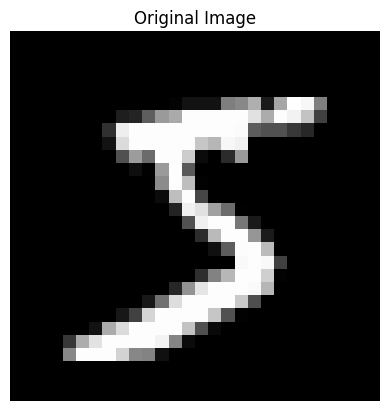

In [9]:
# Display the original image
plt.imshow(sample_image[0, :, :, 0], cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# 🧪 Step 10 — Show all 4 feature maps


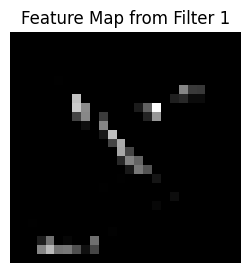

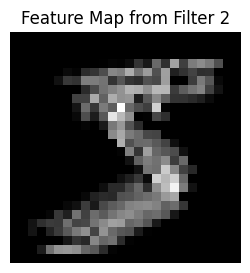

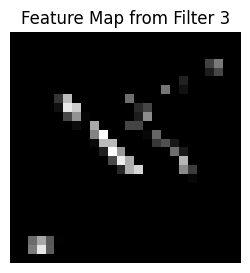

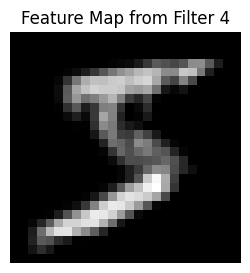

In [10]:
# Loop through all 4 feature maps and display them one by one
for i in range(4):
    plt.figure(figsize=(3, 3))
    
    # Show one feature map at a time
    plt.imshow(feature_maps[0, :, :, i], cmap="gray")
    
    # Give a title so students know which feature map they are seeing
    plt.title(f"Feature Map from Filter {i+1}")
    
    # Remove axis values for cleaner view
    plt.axis("off")
    
    # Display the feature map
    plt.show()



---

# 🧠 What We should observe

Even though the input image is one digit, each filter creates a slightly different output.

Why?

Because each filter is checking for a different pattern.

One may react more to top strokes.
One may react to side edges.
One may react to curves.
One may react to bright-dark changes.

That is why the outputs are different.

---


# 🧪 Step 11 — See filter weights directly


In [11]:
# Get the learned weights of the convolution layer
filters, biases = model.layers[0].get_weights()

# Print shape of filter weights
print("Filter weights shape:", filters.shape)

Filter weights shape: (3, 3, 1, 4)




```

Possible output:

```text
Filter weights shape: (3, 3, 1, 4)
```

---

# 🧠 What does `(3, 3, 1, 4)` mean?

This is super important.

It means:

* filter height = 3
* filter width = 3
* input channels = 1
* number of filters = 4

So CNN created:

```text
4 filters of size 3×3
```

because image has 1 channel.

---

# 🧪 Step 12 — Print one filter values


In [12]:

# Print values of the first filter
print("First filter values:")
print(filters[:, :, 0, 0])


First filter values:
[[-0.17522386  0.3362218  -0.02620023]
 [-0.3102332   0.32840556 -0.19608796]
 [-0.04275948 -0.32566202  0.00955769]]


```

This will show something like:

```text
[[ 0.12 -0.31  0.08]
 [ 0.44  0.10 -0.27]
 [-0.15  0.19  0.35]]
```

These are the actual numbers inside the filter.

At this stage, they are usually random or untrained.

---





# 🧠 Big  moment

> **See? You did not manually type these numbers.**
> CNN created them and will improve them during training.

This is a key idea we must remember.

---

# 🤖 Milo’s super simple summary

```text
A filter is a small matrix of numbers.
It moves over the image and checks for patterns.
CNN does not need us to manually create filter values.
It learns those values automatically during training.
```

---

# 📊 Mini recap table

| Thing           | Meaning                          |
| --------------- | -------------------------------- |
| Filter / Kernel | small matrix that scans image    |
| 3×3 filter      | filter with 3 rows and 3 columns |
| 1 filter        | gives 1 feature map              |
| 4 filters       | gives 4 feature maps             |
| filter values   | learned during training          |

---



# 🧪  practice


### Practice 1 — Change number of filters

```python
model = models.Sequential()
model.add(layers.Conv2D(8, (3, 3), activation="relu", input_shape=(28, 28, 1)))
```

Ask:

```text
How many feature maps do you get now?
```

---

### Practice 2 — Change filter size

```python
model = models.Sequential()
model.add(layers.Conv2D(4, (5, 5), activation="relu", input_shape=(28, 28, 1)))
```

Ask:

```text
Did the output shape change?
```

---

### Practice 3 — Print another filter

```python
print(filters[:, :, 0, 1])
```

Ask:

```text
Are the values same as filter 1 or different?
```

---

